Loading dataset: 'ses-001_task-s01e02a'
Successfully loaded data. Shape: (482, 1000)
Randomly selected parcel indices: [605]
Rendering the plot...


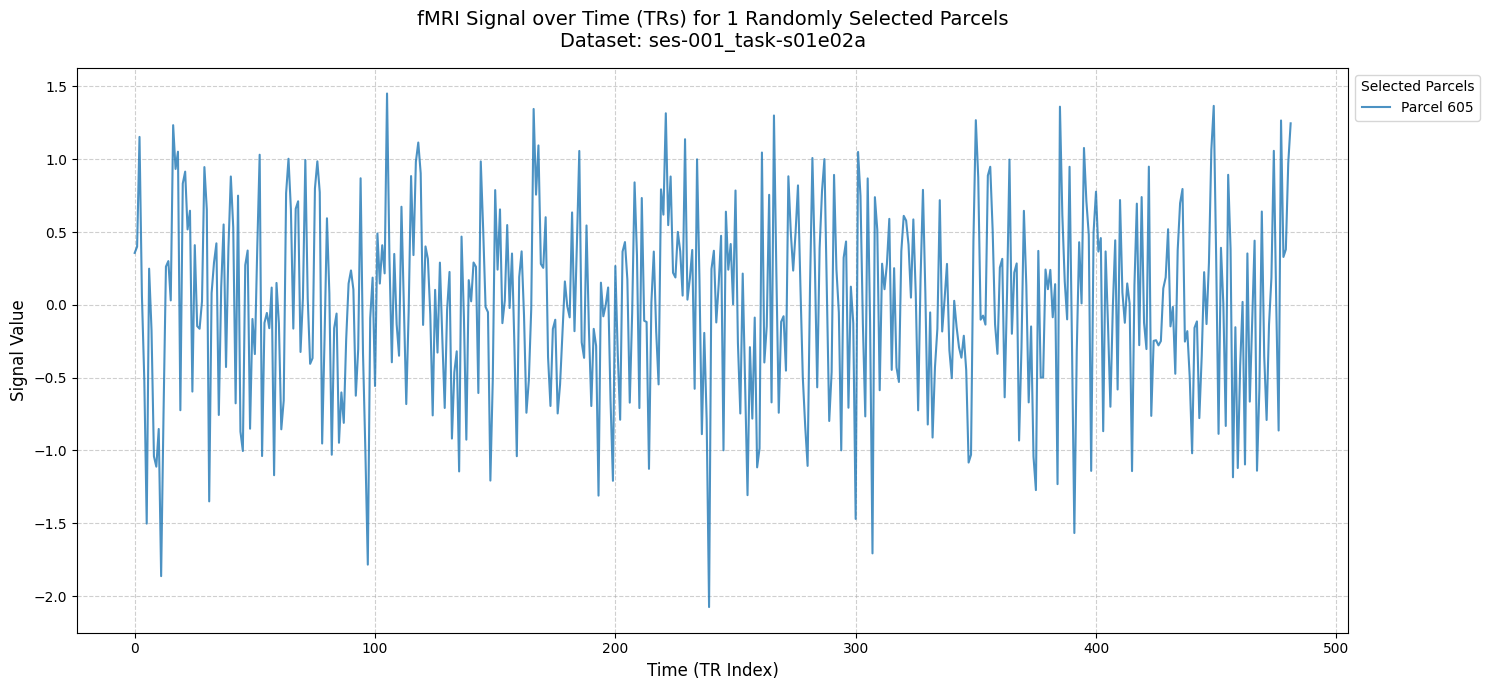

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to the HDF5 file
file_path = "/media/hung/HDD/workplaces/codes/multimodal/agusta/Data/algonauts_2025.competitors/fmri/sub-01/func/sub-01_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"

# Target dataset to visualize
dataset_name = "ses-001_task-s01e02a"
num_parcels_to_plot = 1

try:
    # Open the HDF5 file in read-only mode
    with h5py.File(file_path, "r") as f:
        print(f"Loading dataset: '{dataset_name}'")
        
        # Load the data into a numpy array
        # The data shape should be (482, 1000) for this specific dataset
        data = f[dataset_name][:]
        print(f"Successfully loaded data. Shape: {data.shape}")
        
        num_trs = data.shape[0]
        total_parcels = data.shape[1]
        
        # Randomly select 10 unique parcel indices
        # np.random.seed(42)  # Uncomment this if you want the same random parcels every time
        selected_parcels = np.random.choice(total_parcels, size=num_parcels_to_plot, replace=False)
        selected_parcels.sort() # Sort indices for better visualization in legend
        print(f"Randomly selected parcel indices: {selected_parcels}")
        
        # Create the time axis (X-axis) representing TR indices
        time_axis = np.arange(num_trs)
        
        # Set up the plot figure size for better readability
        plt.figure(figsize=(15, 7))
        
        # Plot the signal across all TRs for each selected parcel
        for parcel_idx in selected_parcels:
            parcel_signal = data[:, parcel_idx]
            plt.plot(time_axis, parcel_signal, label=f"Parcel {parcel_idx}", linewidth=1.5, alpha=0.8)
            
        # Customize the plot
        plt.title(f"fMRI Signal over Time (TRs) for {num_parcels_to_plot} Randomly Selected Parcels\nDataset: {dataset_name}", fontsize=14, pad=15)
        plt.xlabel("Time (TR Index)", fontsize=12)
        plt.ylabel("Signal Value", fontsize=12)
        
        # Add a grid for easier reading
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Add legend outside the plot area so it doesn't overlap with the signal lines
        plt.legend(title="Selected Parcels", loc='upper left', bbox_to_anchor=(1, 1))
        
        # Adjust layout to prevent the legend from being cut off
        plt.tight_layout()
        
        # Display the plot
        print("Rendering the plot...")
        plt.show()

except KeyError:
    print(f"Error: The dataset '{dataset_name}' does not exist in the HDF5 file.")
except Exception as e:
    print(f"An unexpected error occurred during processing: {e}")
